# EDA 3 — is the shortlist finding structure, or just long provisions?

The candidate score sums marker weights. EDA 2 showed marker hits correlate
with length at about 0.73 Spearman, so the obvious worry is that the shortlist
is a length ranking wearing a normative costume. This page tests that directly,
on `candidates.parquet`. No API calls.

A shortlist that were only length would still be usable — but it would have to
be described as "long provisions", and the sampling argument for the probe
passages would change.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from simulacria.pipeline.silver import POOLS
from simulacria.pipeline.store import connect

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 210)
pd.set_option("display.max_colwidth", 80)


def pool(name: str) -> dict[str, pd.DataFrame]:
    connection = connect(POOLS[name].tables_dir)
    return {
        "candidates": connection.execute("select * from candidates").df(),
        "provisions": connection.execute(
            "select provision_id, document_id, document_title, char_count, text from provisions"
        ).df(),
    }


v1 = pool("v1")
candidates, provisions = v1["candidates"], v1["provisions"]
print(
    f"v1: {len(candidates)} candidates surfaced from {len(provisions):,} provisions "
    f"({len(candidates) / len(provisions):.1%})"
)

v1: 461 candidates surfaced from 1,952 provisions (23.6%)


## 1. What the score is made of

In [2]:
display(candidates.score.describe(percentiles=[0.25, 0.5, 0.75, 0.9]).to_frame().T)
display(
    pd.DataFrame(
        {
            "has_duty": [candidates.has_duty.mean()],
            "has_exception": [candidates.has_exception.mean()],
            "has_qualifier": [candidates.has_qualifier.mean()],
            "all three": [
                (candidates.has_duty & candidates.has_exception & candidates.has_qualifier).mean()
            ],
        }
    ).round(3)
)
display(candidates.determinacy.value_counts().rename("candidates").to_frame())
display(candidates.qualifier_determinacy.value_counts().rename("candidates").to_frame())

,count,mean,std,min,25%,50%,75%,90%,max
score,461.0,12.060738,3.081607,5.0,10.0,12.0,14.0,16.0,21.0


,has_duty,has_exception,has_qualifier,all three
0,1.0,1.0,1.0,1.0


,candidates
determinacy,
unmarked,298
specific,119
vague,44


,candidates
qualifier_determinacy,
unmarked,381
specific,52
vague,28


## 2. Score against length

If the score were a length proxy, rank and length would move together and the
scatter would be a line. The correlation below is the headline number of this
page.

score vs characters — Spearman 0.20, Pearson 0.14


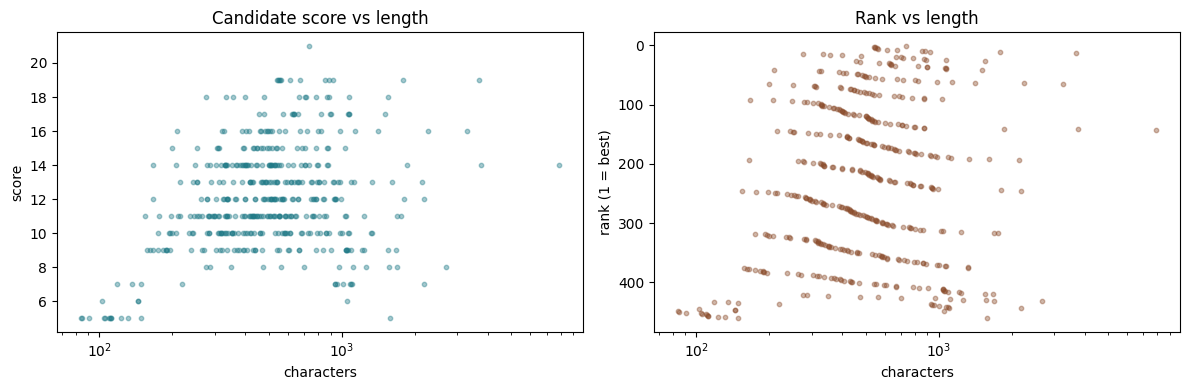

In [3]:
merged = candidates.merge(provisions, on="provision_id", suffixes=("", "_prov"))
spearman = merged.score.corr(merged.char_count, method="spearman")
pearson = merged.score.corr(merged.char_count)
print(f"score vs characters — Spearman {spearman:.2f}, Pearson {pearson:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(merged.char_count, merged.score, s=10, alpha=0.4, color="#207a87")
axes[0].set(xlabel="characters", ylabel="score", title="Candidate score vs length", xscale="log")
axes[1].scatter(merged.char_count, merged["rank"], s=10, alpha=0.4, color="#8a4b2a")
axes[1].set(xlabel="characters", ylabel="rank (1 = best)", title="Rank vs length", xscale="log")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

## 3. The length-controlled question

Within a narrow length band, do candidates still differ from non-candidates in
the structure they carry? If yes, the score is doing something length alone
does not.

In [4]:
provisions = provisions.assign(is_candidate=provisions.provision_id.isin(candidates.provision_id))
band = provisions[(provisions.char_count >= 250) & (provisions.char_count <= 600)]
print(
    f"length band 250-600 characters: {len(band):,} provisions, "
    f"{band.is_candidate.sum():,} of them candidates ({band.is_candidate.mean():.1%})"
)

structure = band.assign(
    has_dock=band.text.str.contains(r"\bdock\b", case=False, regex=True, na=False),
    has_om_inte=band.text.str.contains(r"\bom inte\b", case=False, regex=True, na=False),
    has_ska=band.text.str.contains(r"\bska\b", case=False, regex=True, na=False),
    has_far_inte=band.text.str.contains(r"\bfår inte\b", case=False, regex=True, na=False),
)
display(
    structure.groupby("is_candidate")[["has_dock", "has_om_inte", "has_ska", "has_far_inte"]]
    .mean()
    .round(3)
)
print(
    "Read as: within one length band, the share of provisions containing each\n"
    "pattern, for candidates and non-candidates. A large gap means the score is\n"
    "tracking wording, not size."
)

length band 250-600 characters: 877 provisions, 245 of them candidates (27.9%)


,has_dock,has_om_inte,has_ska,has_far_inte
is_candidate,,,,
False,0.025,0.006,0.576,0.074
True,0.363,0.131,0.665,0.098


Read as: within one length band, the share of provisions containing each
pattern, for candidates and non-candidates. A large gap means the score is
tracking wording, not size.


## 4. Where candidates come from

If a single act supplies most of the shortlist, "the corpus says" is really
"this one law says".

In [5]:
source = (
    candidates.merge(provisions, on="provision_id", suffixes=("", "_prov"))
    .groupby("document_title")
    .agg(candidates=("provision_id", "count"), best_rank=("rank", "min"))
    .sort_values("candidates", ascending=False)
)
display(source.head(10))
top50 = candidates.nsmallest(50, "rank").merge(provisions, on="provision_id")
print(f"The top 50 candidates come from {top50.document_id.nunique()} distinct documents.")

,candidates,best_rank
document_title,,
Elmarknadslag (2026:1281),72,21
Vapenlag (2026:408),38,10
Konsumentkreditlag (2026:1011),36,11
Lag (1982:80) om anställningsskydd,36,5
Mottagandelag (2026:999),29,17
Lag (2026:1283) om elektriska ledningar,24,4
Lag (1976:580) om medbestämmande i arbetslivet,20,23
Privatuthyrningslag (2026:772),19,28
Semesterlag (1977:480),19,3


The top 50 candidates come from 20 distinct documents.


## 5. v1 against v2

The larger pool is nearly ten times the size. If the candidate rate and the
determinacy mix hold, the heuristic behaves consistently; if they move, the
v1 numbers were partly a property of those 50 laws.

In [6]:
try:
    v2 = pool("v2")
except SystemExit as missing:
    print(f"v2 tables not built: {missing}")
else:
    summary = pd.DataFrame(
        [
            {
                "pool": name,
                "provisions": len(data["provisions"]),
                "candidates": len(data["candidates"]),
                "candidate_rate": round(len(data["candidates"]) / len(data["provisions"]), 4),
                "median_score": data["candidates"].score.median(),
                "specific_share": round((data["candidates"].determinacy == "specific").mean(), 3),
                "all_three_share": round(
                    (
                        data["candidates"].has_duty
                        & data["candidates"].has_exception
                        & data["candidates"].has_qualifier
                    ).mean(),
                    3,
                ),
            }
            for name, data in (("v1", v1), ("v2", v2))
        ]
    )
    display(summary)

,pool,provisions,candidates,candidate_rate,median_score,specific_share,all_three_share
0,v1,1952,461,0.2362,12.0,0.258,1.0
1,v2,18836,4071,0.2161,11.0,0.206,1.0


## 6. What this page settles, and what it does not

It settles whether the shortlist is a disguised length ranking: read the
correlation in section 2 and the length-controlled gaps in section 3 together.

It does not say anything about whether a candidate is *normatively*
interesting. That judgement is what the hand-annotated slots are for, and the
three probe passages were chosen by reading, with the shortlist only deciding
where to look.